# 254. Factor Combinations
https://leetcode.com/problems/factor-combinations/

## Complexity Comparison

| Approach | Time | Space | Description |
|----------|------|-------|-------------|
| **Backtracking** | **O(n log n)** | **O(log n)** | **Try each factor >= start, recurse on quotient** |

## Methodology

We use **backtracking** to find all factor combinations. Starting from factor 2, for each candidate factor `f` that divides `n`, we include `f` in the current combination and recurse on `n/f`. To avoid duplicates, we ensure factors are non-decreasing by passing the minimum allowed factor. The recursion adds the remaining quotient as the last factor when it is >= the current minimum factor.

## Solutions

### C#

In [ ]:
// 254. Factor Combinations
// Time: O(n log n) | Space: O(log n)
public class Solution {
    public IList<IList<int>> GetFactors(int n) {
        var result = new List<IList<int>>();
        Backtrack(n, 2, new List<int>(), result);
        return result;
    }
    
    private void Backtrack(int n, int start, List<int> path, List<IList<int>> result) {
        for (int f = start; f * f <= n; f++) {
            if (n % f == 0) {
                path.Add(f);
                path.Add(n / f);
                result.Add(new List<int>(path));
                path.RemoveAt(path.Count - 1);
                Backtrack(n / f, f, path, result);
                path.RemoveAt(path.Count - 1);
            }
        }
    }
}

### Python

In [ ]:
# 254. Factor Combinations
# Time: O(n log n) | Space: O(log n)
class Solution:
    def getFactors(self, n: int) -> list[list[int]]:
        result = []
        
        def backtrack(n, start, path):
            f = start
            while f * f <= n:
                if n % f == 0:
                    result.append(path + [f, n // f])
                    backtrack(n // f, f, path + [f])
                f += 1
        
        backtrack(n, 2, [])
        return result

### Go

In [ ]:
// 254. Factor Combinations
// Time: O(n log n) | Space: O(log n)
func getFactors(n int) [][]int {
    var result [][]int
    var backtrack func(int, int, []int)
    
    backtrack = func(n, start int, path []int) {
        for f := start; f*f <= n; f++ {
            if n%f == 0 {
                combo := make([]int, len(path)+2)
                copy(combo, path)
                combo[len(path)] = f
                combo[len(path)+1] = n / f
                result = append(result, combo)
                backtrack(n/f, f, append(path, f))
            }
        }
    }
    
    backtrack(n, 2, nil)
    return result
}

### Rust

In [ ]:
// 254. Factor Combinations
// Time: O(n log n) | Space: O(log n)
impl Solution {
    pub fn get_factors(n: i32) -> Vec<Vec<i32>> {
        let mut result = Vec::new();
        Self::backtrack(n, 2, &mut Vec::new(), &mut result);
        result
    }
    
    fn backtrack(n: i32, start: i32, path: &mut Vec<i32>, result: &mut Vec<Vec<i32>>) {
        let mut f = start;
        while f * f <= n {
            if n % f == 0 {
                path.push(f);
                path.push(n / f);
                result.push(path.clone());
                path.pop();
                Self::backtrack(n / f, f, path, result);
                path.pop();
            }
            f += 1;
        }
    }
}

## Example Scenarios

1. **Common Case** — Small composite number  
   **Input:** `n = 12`  
   Backtrack starting from factor 2. Combinations: $[2, 6], [2, 2, 3], [3, 4]$. We avoid $[1, 12]$ and $[12]$ per the problem rules. Each path explores factors $\geq$ the previous to avoid duplicates. Answer: 3 combinations.

2. **Slightly Complex** — Number with many factor paths  
   **Input:** `n = 32`  
   Powers of 2 yield many decompositions: $[2, 16], [2, 2, 8], [2, 2, 2, 4], [2, 2, 2, 2, 2], [2, 4, 4], [4, 8]$. The backtracking tree branches at each power of 2, producing $6$ total combinations.

3. **Edge Case: Time Factor** — Large number with many small factors  
   **Input:** `n = 2^{10} \times 3^{5} = 248832$  
   The backtracking tree is deep (up to $\log_2 n \approx 18$ levels) and wide (many factor choices at each level). The number of valid combinations grows combinatorially with the exponents in the prime factorization.

4. **Edge Case: Space Factor** — Prime number  
   **Input:** `n = 997` (prime)  
   No factor between 2 and $\lfloor\sqrt{997}\rfloor = 31$ divides 997. The backtracking explores all candidates $2..31$ without finding any, so the recursion tree is shallow and the result list is empty. Answer: $[]$.

5. **Almost-Impossible but Plausible** — Boundary value  
   **Input:** `n = 2^{31} - 1 = 2147483647$  
   This is a Mersenne prime. The loop checks all factors from 2 to $\lfloor\sqrt{2147483647}\rfloor = 46340$. None divides it evenly. The result is $[]$. Tests that the solution handles large 32-bit values without overflow or timeout.


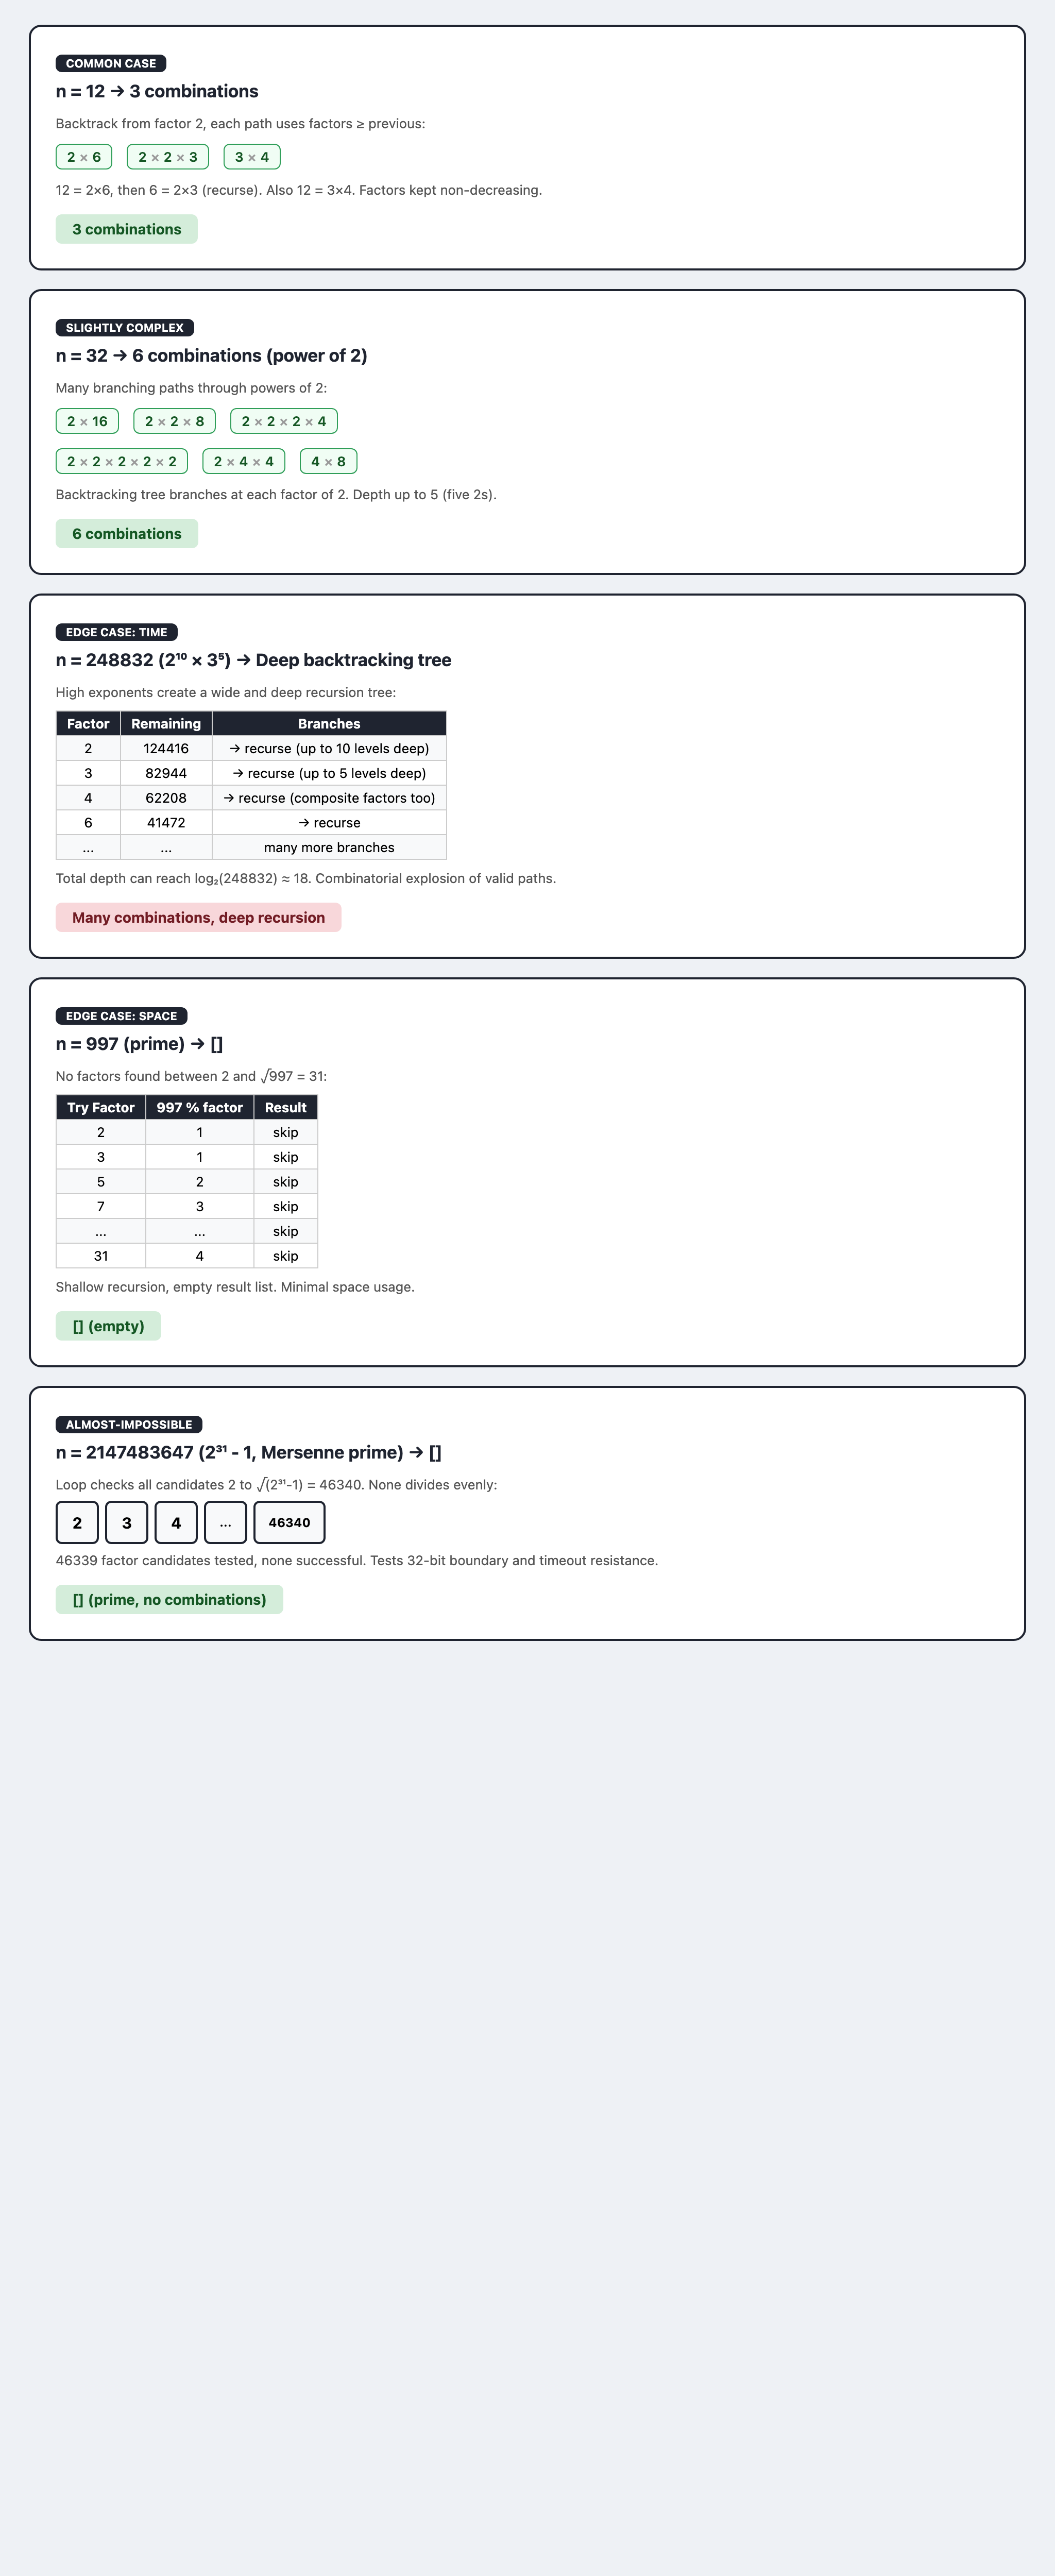